In [ ]:
## Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os


2025-10-26 19:06:29.314869: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-26 19:06:29.387724: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-26 19:06:31.332982: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
## Load your dataset

In [18]:
data_dir = "/home/bulipe/ML-practices/ML_datasets/vehicle_data"

# Training dataset
train_ds = image_dataset_from_directory(
    os.path.join(data_dir, "train"),
    image_size=(128, 128),
    batch_size=32,
    label_mode="int"  # class indices
)

# Validation dataset
val_ds = image_dataset_from_directory(
    os.path.join(data_dir, "val"),
    image_size=(128, 128),
    batch_size=32,
    label_mode="int"
)

# Get class names
class_names = train_ds.class_names
print("Classes:", class_names)


Found 1280 files belonging to 2 classes.
Found 310 files belonging to 2 classes.
Classes: ['Cars', 'Motorcycles']


In [ ]:
# Check sample images

2025-10-26 19:32:16.399120: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


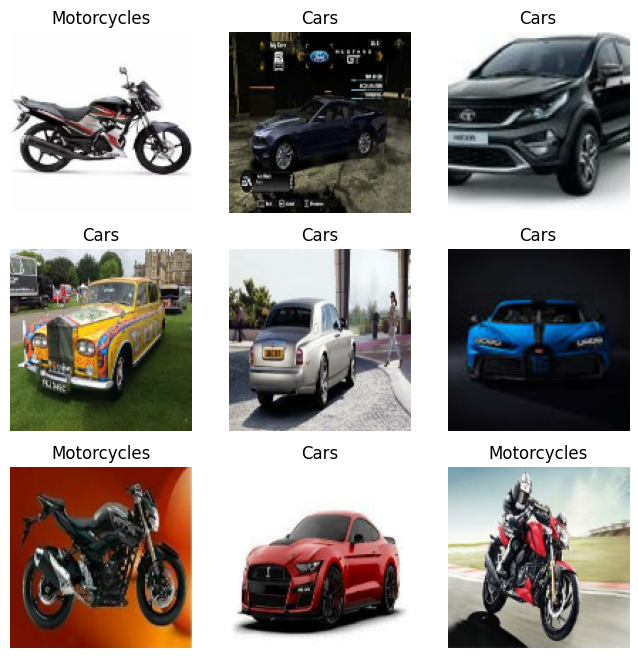

In [19]:

class_names = train_ds.class_names
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")


In [ ]:
# Normalize and prepare data

In [4]:
# Normalize pixel values (0-1)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


In [ ]:
# Build a simple CNN model

In [5]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/home/bulipe/miniconda3/envs/vehImgClassification/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10  # you can increase later
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 469ms/step - accuracy: 0.6219 - loss: 0.6567 - val_accuracy: 0.7484 - val_loss: 0.4676
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 465ms/step - accuracy: 0.8562 - loss: 0.3237 - val_accuracy: 0.8935 - val_loss: 0.2682
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 471ms/step - accuracy: 0.9055 - loss: 0.2407 - val_accuracy: 0.9000 - val_loss: 0.2440
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 463ms/step - accuracy: 0.9328 - loss: 0.1582 - val_accuracy: 0.9194 - val_loss: 0.2447
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 467ms/step - accuracy: 0.9547 - loss: 0.1234 - val_accuracy: 0.9290 - val_loss: 0.1897
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step - accuracy: 0.9789 - loss: 0.0631 - val_accuracy: 0.8839 - val_loss: 0.4005
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step - accuracy: 0.9781 - loss: 0.0490 - val_accuracy: 0.9129 - val_loss: 0.2930
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 462ms/step - accuracy: 0.9984 - loss: 0.0142 - val_accu

In [ ]:
# Plot training metrics

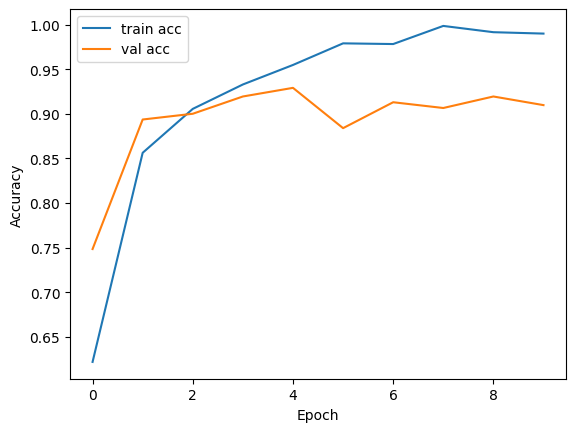

In [7]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Evaluate with confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


2025-10-26 19:17:30.573133: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


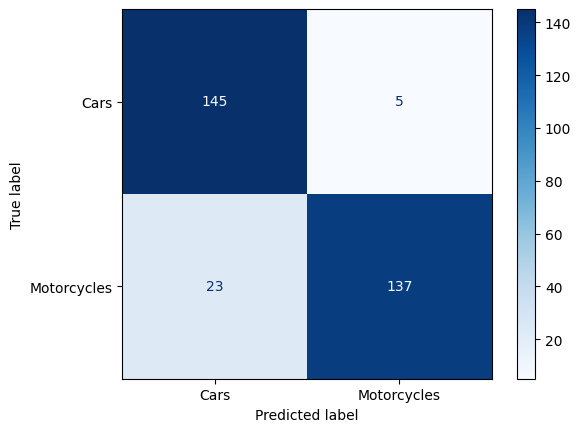

In [8]:
y_true, y_pred = [], []

for imgs, labels in val_ds:
    preds = model.predict(imgs)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.show()


In [ ]:
# Save trained model

In [9]:
# Save in Keras native format
model.save("vehicle_classifier.keras")


In [ ]:
# Evaluate model on validation set

In [10]:
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.2f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.9097 - loss: 0.4683
Validation Accuracy: 0.91


In [ ]:
# Predict a single image

In [20]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import tensorflow as tf

# Example image path (change this to your local image)
#img_path = "/home/bulipe/ML-practices/ML_datasets/vehicle_data/val/Cars/Car (43).jpg"
img_path = "/home/bulipe/ML-practices/ML_datasets/vehicle_data/val/Motorcycles/Motorcycle (2).jpg"

# Load and preprocess image
img = load_img(img_path, target_size=(128, 128))  # same size as your training
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

# Predict
pred = model.predict(img_array)
score = tf.nn.softmax(pred[0])

print(
    f"Predicted: {class_names[np.argmax(score)]} "
    f"with confidence: {100 * np.max(score):.2f}%"
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Predicted: Motorcycles with confidence: 73.11%


In [ ]:
# (Optional) Visualize the image with its prediction

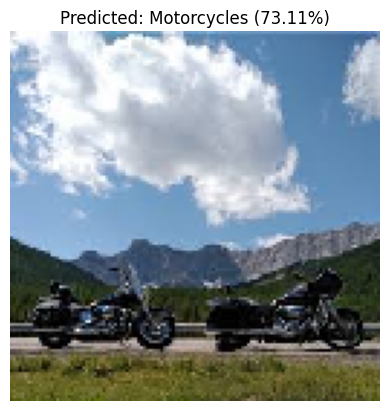

In [21]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted: {class_names[np.argmax(score)]} "
          f"({100*np.max(score):.2f}%)")
plt.axis("off")
plt.show()


In [24]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import tensorflow as tf

# Example image path (change this to your local image)
img_path = "/home/bulipe/ML-practices/ML_datasets/vehicle_data/val/Cars/Car (5).jpg"
#img_path = "/home/bulipe/ML-practices/ML_datasets/vehicle_data/val/Motorcycles/Motorcycle (20).jpg"

# Load and preprocess image
img = load_img(img_path, target_size=(128, 128))  # same size as your training
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension

# Predict
pred = model.predict(img_array)
score = tf.nn.softmax(pred[0])

print(
    f"Predicted: {class_names[np.argmax(score)]} "
    f"with confidence: {100 * np.max(score):.2f}%"
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted: Cars with confidence: 73.11%


In [ ]:
# (Optional) Visualize the image with its prediction

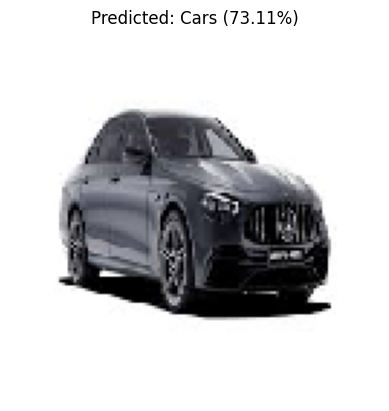

In [25]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predicted: {class_names[np.argmax(score)]} "
          f"({100*np.max(score):.2f}%)")
plt.axis("off")
plt.show()
